``CPP().simplify()`` rewrites a fitted ``df_feat`` into a **more interpretable, and ideally smaller** one. For each feature (``PART-SPLIT-SCALE``) it swaps the scale for a *correlated* scale from a **better-graded AAontology subcategory** (interpretability grade 1-10, where **grade 1 is the best, so lower is better**), recomputes the feature statistics, and accepts the swap only if it keeps passing CPP filtering and does not reduce a cross-validation score. The swapped set is then redundancy-reduced **without dropping any original feature** (only a swapped feature that became redundant is removed). We start from a precomputed DOM_GSEC feature set (see [Breimann25]_), which already carries ``feat_importance``:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False
df_feat = aa.load_features(name="DOM_GSEC")
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
# Reproducibility: the CV-gate model is seeded from the CPP instance's random_state
cpp = aa.CPP(df_parts=df_parts, random_state=0)
aa.display_df(df_feat, n_rows=5, show_shape=True)

DataFrame shape: (150, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...3,4)-HUTJ700102",Energy,Entropy,Entropy,"Absolute entrop...Hutchens, 1970)",0.229000,0.098224,0.098224,0.106865,0.124608,0.000000,0.000001,"31,32,33,34,35",3.111200,3.109955
5,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000


With only ``df_feat`` and ``labels``, ``simplify`` runs the default ``greedy`` strategy with an SVM cross-validation gate and returns the simplified feature set:

In [2]:
df_simple = cpp.simplify(df_feat=df_feat, labels=labels)
aa.display_df(df_simple, show_shape=True)

DataFrame shape: (94, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
5,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
7,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
8,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
9,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
10,"TMD_C_JMD_C-Seg...6,9)-CHOC760103",ASA/Volume,Buried,Buried,"Proportion of r...(Chothia, 1976)",0.205000,0.125868,-0.125868,0.172165,0.188333,0.000000,0.000009,"32,33",0.000000,0.000000


``max_interpret_grade`` caps the worst interpretability grade allowed to remain (1 = best). With ``max_interpret_grade=2`` every feature graded worse than 2 is targeted for replacement; if it is ``None`` (default) every improvable feature is attempted:

In [3]:
df_grade = cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=2)
aa.display_df(df_grade, show_shape=True)

DataFrame shape: (96, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
5,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
7,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
8,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
9,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
10,"TMD_C_JMD_C-Seg...6,9)-CHOC760103",ASA/Volume,Buried,Buried,"Proportion of r...(Chothia, 1976)",0.205000,0.125868,-0.125868,0.172165,0.188333,0.000000,0.000009,"32,33",0.000000,0.000000


The **strategy** controls how swaps are chosen and validated. ``greedy`` swaps feature by feature behind the CV gate; ``consolidate`` batches features by subcategory toward the fewest subcategories; ``swap_all`` applies every eligible swap with no cross-validation (fastest):

In [4]:
import pandas as pd
rows = []
for strategy in ["greedy", "consolidate", "swap_all"]:
    out = cpp.simplify(df_feat=df_feat, labels=labels, strategy=strategy)
    rows.append([strategy, len(out), out["subcategory"].nunique()])
df_strategies = pd.DataFrame(rows, columns=["strategy", "n_features", "n_subcategories"])
aa.display_df(df_strategies)

,strategy,n_features,n_subcategories
1,greedy,94,25
2,consolidate,92,25
3,swap_all,94,25


The **candidate_search** mode trades exactness for speed. ``exact`` (default) tests every eligible candidate per feature and reproduces the result exactly; ``fast`` is an opt-in heuristic that caps the search to the most promising candidates (best interpretability, then strongest correlation), which speeds up large scale pools — it mainly accelerates ``greedy`` (``swap_all`` already stops at the first viable candidate). The kept-feature set stays close to ``exact``:

In [5]:
df_exact = cpp.simplify(df_feat=df_feat, labels=labels, candidate_search="exact")
df_fast = cpp.simplify(df_feat=df_feat, labels=labels, candidate_search="fast")
kept_exact, kept_fast = set(df_exact["feature"]), set(df_fast["feature"])
jaccard = len(kept_exact & kept_fast) / len(kept_exact | kept_fast)
df_cs = pd.DataFrame([["exact", len(df_exact)], ["fast", len(df_fast)]],
                     columns=["candidate_search", "n_features"])
print(f"kept-feature Jaccard (fast vs exact): {jaccard:.2f}")
aa.display_df(df_cs)

kept-feature Jaccard (fast vs exact): 1.00


,candidate_search,n_features
1,exact,94
2,fast,94


The **cross-validation gate** (``greedy`` / ``consolidate``) decides whether a swap is kept. ``ml_model`` selects the classifier — a preset ``'svm'`` (default; fast), ``'rf'`` (recommended for non-linear relationships, slower), or ``'log_reg'`` (fastest), or a custom scikit-learn estimator instance. ``ml_metric`` is the scoring metric, ``ml_cv`` the number of folds, and ``ml_th`` the tolerated CV-score drop (a swap is kept if its score is at least ``baseline - ml_th``):

In [6]:
df_rf = cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=2,
                     ml_model="rf", ml_metric="accuracy", ml_cv=3, ml_th=0.05)
aa.display_df(df_rf, show_shape=True)

DataFrame shape: (96, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
5,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
7,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
8,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
9,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
10,"TMD_C_JMD_C-Seg...6,9)-CHOC760103",ASA/Volume,Buried,Buried,"Proportion of r...(Chothia, 1976)",0.205000,0.125868,-0.125868,0.172165,0.188333,0.000000,0.000009,"32,33",0.000000,0.000000


A custom estimator instance can be passed directly as ``ml_model`` (used as-is):

In [7]:
from sklearn.svm import SVC
df_custom = cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=2,
                         ml_model=SVC(kernel="linear"))
aa.display_df(df_custom, show_shape=True)

DataFrame shape: (109, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
5,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
7,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
8,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
9,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
10,"TMD_C_JMD_C-Seg...6,9)-CHOC760103",ASA/Volume,Buried,Buried,"Proportion of r...(Chothia, 1976)",0.205000,0.125868,-0.125868,0.172165,0.188333,0.000000,0.000009,"32,33",0.000000,0.000000


**Candidate eligibility and per-feature filtering.** ``min_cor`` is the minimum absolute correlation a candidate scale must have with the original scale (anti-correlation allowed), and ``max_std_test`` is the CPP per-feature pre-filter threshold the recomputed swapped feature must satisfy:

In [8]:
df_strict = cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=2,
                         min_cor=0.8, max_std_test=0.2)
aa.display_df(df_strict, show_shape=True)

DataFrame shape: (120, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
5,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
7,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
8,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
9,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
10,"TMD_C_JMD_C-Seg...3,4)-KOEH090106",Polarity,Hydrophilicity,Polarity (hydrophilicity),Hydrophobicity ...r et al. (2009),0.289000,0.193943,0.193943,0.159718,0.184043,0.000000,0.000000,"31,32,33,34,35",nan,nan


**Unimprovable features.** When a targeted feature has no accepted swap, ``on_unimprovable`` decides its fate: ``'keep'`` (retain the original, default), ``'drop'`` (remove it), or ``'drop_if_perf_allows'`` (remove only if the CV score does not drop). The last feature is never dropped:

In [9]:
df_drop = cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=2,
                       on_unimprovable="drop")
aa.display_df(df_drop, show_shape=True)

DataFrame shape: (78, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
3,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
4,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
5,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
6,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
7,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
8,"TMD_C_JMD_C-Seg...6,9)-CHOC760103",ASA/Volume,Buried,Buried,"Proportion of r...(Chothia, 1976)",0.205000,0.125868,-0.125868,0.172165,0.188333,0.000000,0.000009,"32,33",0.000000,0.000000
9,"TMD_C_JMD_C-Seg...4,5)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.204000,0.105513,0.105513,0.132849,0.145219,0.000000,0.000009,"33,34,35,36",1.992000,2.929460
10,"JMD_N_TMD_N-Seg...1,2)-KARP850101",Structure-Activity,Flexibility,Flexibility (0 ...igid neighbors),"Flexibility par...s-Schulz, 1985)",0.196000,0.062671,0.062671,0.083456,0.090427,0.000000,0.000023,"1,2,3,4,5,6,7,8,9,10",1.574400,1.835403


**Redundancy reduction** removes only *swapped* features that became redundant — original features are always protected. ``redundancy_tie_break`` chooses the keeper of a redundant pair (``'interpretability'`` or ``'performance'``); ``max_cor`` and ``max_overlap`` are the scale-correlation and position-overlap thresholds; and ``check_cat`` restricts comparisons to the same scale category:

In [10]:
df_red = cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=2,
                      redundancy_tie_break="performance", max_cor=0.5, max_overlap=0.5,
                      check_cat=True)
aa.display_df(df_red, show_shape=True)

DataFrame shape: (96, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
5,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
7,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
8,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
9,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
10,"TMD_C_JMD_C-Seg...6,9)-CHOC760103",ASA/Volume,Buried,Buried,"Proportion of r...(Chothia, 1976)",0.205000,0.125868,-0.125868,0.172165,0.188333,0.000000,0.000009,"32,33",0.000000,0.000000


``label_test`` / ``label_ref`` name the test and reference classes in ``labels`` (default 1 / 0); set them to match a different encoding:

In [11]:
df_lab = cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=2,
                      label_test=1, label_ref=0)
aa.display_df(df_lab, show_shape=True)

DataFrame shape: (96, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
5,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
7,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
8,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
9,"TMD_C_JMD_C-Seg...2,3)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.077355,0.077355,0.102965,0.107453,0.000000,0.000005,"27,28,29,30,31,32,33",3.048800,3.623912
10,"TMD_C_JMD_C-Seg...6,9)-CHOC760103",ASA/Volume,Buried,Buried,"Proportion of r...(Chothia, 1976)",0.205000,0.125868,-0.125868,0.172165,0.188333,0.000000,0.000009,"32,33",0.000000,0.000000


``return_details=True`` additionally returns a long-form table of every candidate scale considered for each feature, with its interpretability grade, correlation with the original scale, recomputed ``std_test``, and whether it was accepted:

In [12]:
df_simple2, df_candidates = cpp.simplify(df_feat=df_feat, labels=labels,
                                         max_interpret_grade=2, return_details=True)
aa.display_df(df_candidates, show_shape=True)

DataFrame shape: (78, 9)


,feature,candidate_scale,interpretability_orig,interpretability_cand,cor,std_test,accepted,cv_score,reason
1,"TMD_C_JMD_C-Seg...6,9)-TANS770106",RADA880101,8.000000,1.000000,-0.742074,0.208957,False,nan,max_std_test
2,"TMD_C_JMD_C-Seg...6,9)-TANS770106",KOEH090103,8.000000,1.000000,0.737712,0.196374,True,0.907051,accepted
3,"TMD-Pattern(C,3...,15)-ANDN920101",FUKS010109,8.000000,1.000000,-0.728856,0.133076,True,0.907051,accepted
4,"TMD_C_JMD_C-Pat...,12)-ANDN920101",FUKS010109,8.000000,1.000000,-0.728856,0.172594,True,0.907051,accepted
5,"TMD_C_JMD_C-Seg...4,5)-TANS770106",RADA880101,8.000000,1.000000,-0.742074,0.162400,True,0.907051,accepted
6,"TMD-Pattern(C,5...,15)-OOBM770105",KARS160117,8.000000,1.000000,-0.959796,0.082837,True,0.907051,accepted
7,"TMD-Pattern(C,4,7)-ANDN920101",FUKS010109,8.000000,1.000000,-0.728856,0.165353,True,0.907051,accepted
8,"TMD_C_JMD_C-Seg...3,4)-MONM990101",KOEH090102,8.000000,1.000000,0.922232,0.134902,True,0.907051,accepted
9,"TMD_C_JMD_C-Pat...3,7)-OOBM770105",KARS160117,8.000000,1.000000,-0.959796,0.117714,True,0.907051,accepted
10,"TMD_C_JMD_C-Seg...2,5)-ANDN920101",FUKS010109,8.000000,1.000000,-0.728856,0.107804,True,0.907051,accepted


``CPPPlot().feature_map`` — the signature CPP visualization — makes the simplification visible: it lays the per-feature mean differences out along the sequence, groups the rows by subcategory, and shows feature importance as the bar track. With 150 features the map is unreadable, so we show the **top 40 features by importance** on a tall canvas. The original feature set already carries ``feat_importance``:

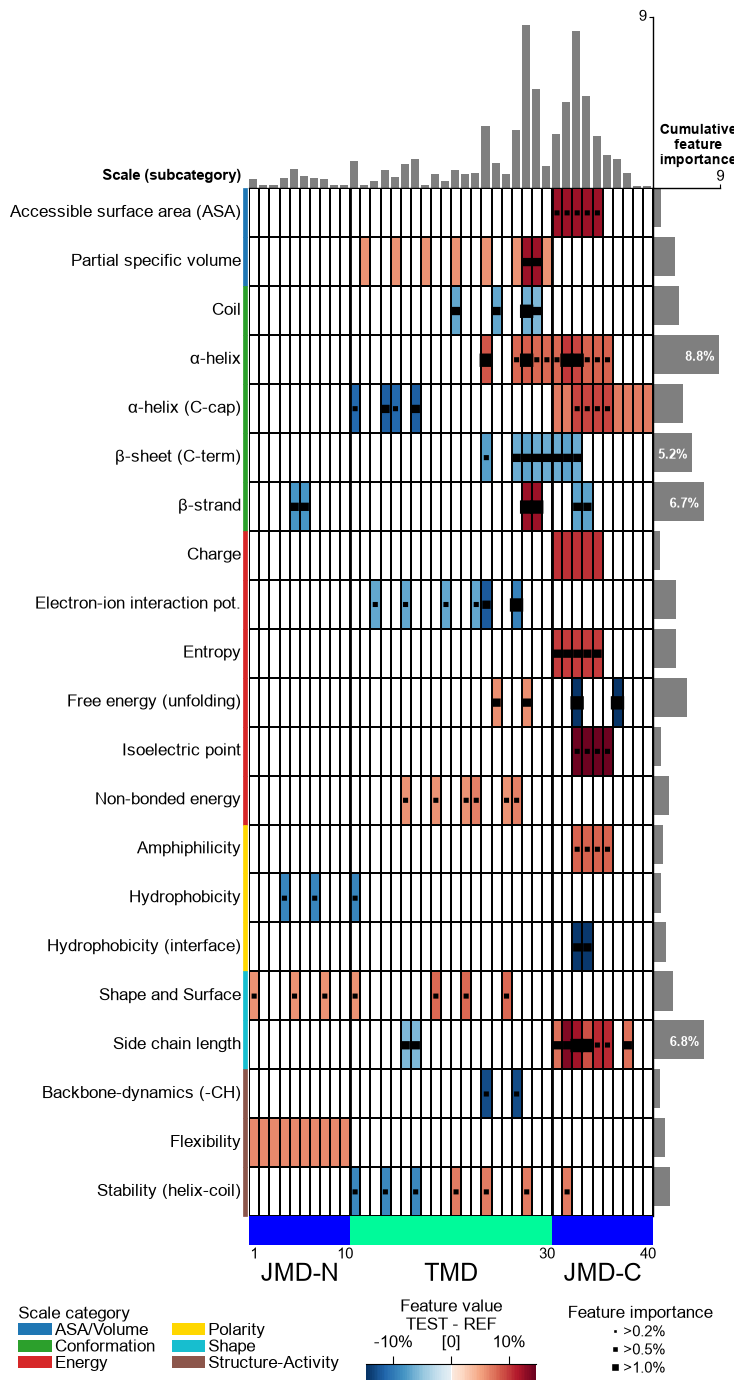

In [13]:
import matplotlib.pyplot as plt
cpp_plot = aa.CPPPlot()
aa.plot_settings(weight_bold=False)
df_feat_top = df_feat.sort_values("feat_importance", ascending=False).head(40)
cpp_plot.feature_map(df_feat=df_feat_top, figsize=(8, 14))
plt.show()

And the **simplified** set (swapped features carry no importance, so we re-attach it with ``TreeModel``) — it speaks in fewer, more interpretable subcategories, with the original (most interpretable) features protected:

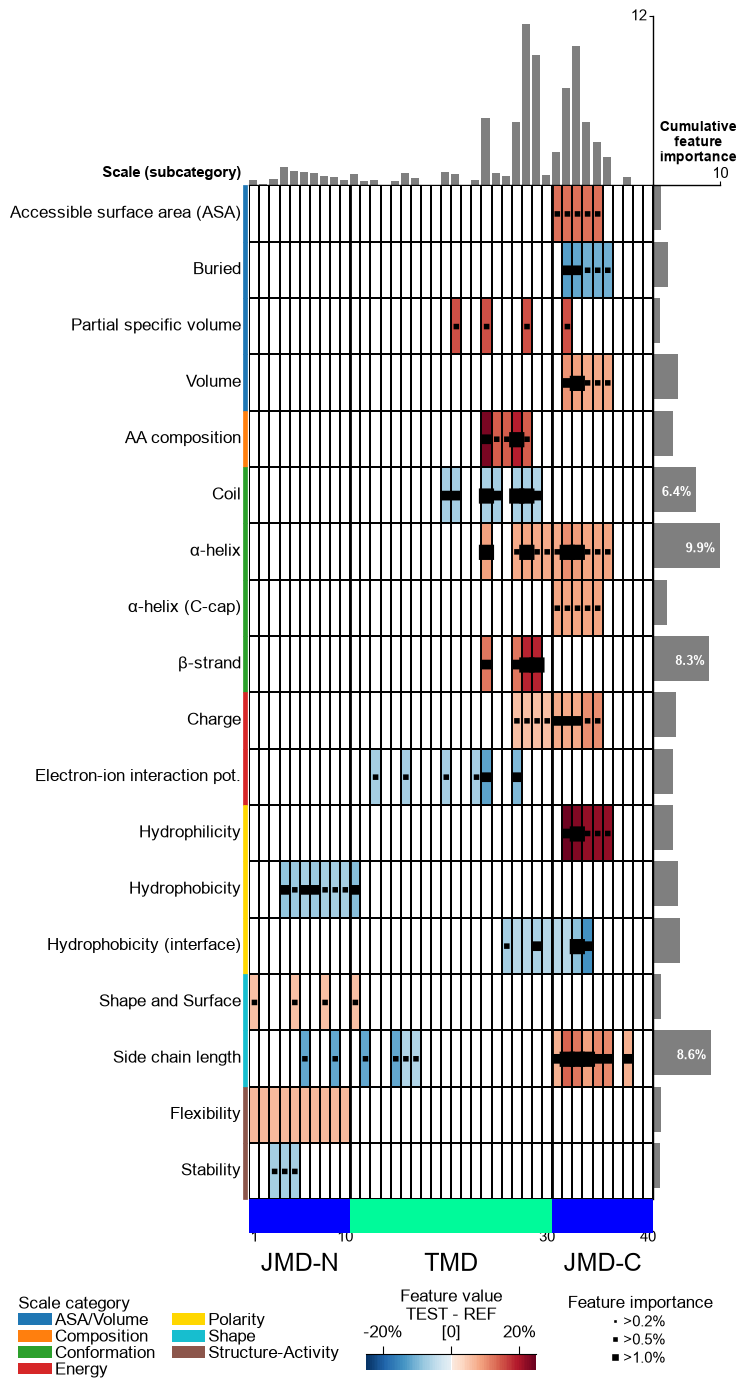

In [14]:
df_scales_all = aa.load_scales()
X = sf.feature_matrix(features=list(df_simple["feature"]), df_parts=df_parts,
                      df_scales=df_scales_all)
df_simple_imp = aa.TreeModel().fit(X, labels=labels).add_feat_importance(df_feat=df_simple, drop=True, sort=True)
df_simple_top = df_simple_imp.head(40)
cpp_plot.feature_map(df_feat=df_simple_top, figsize=(8, 14))
plt.show()

Finally, an overview of how the **subcategory** vocabulary shifts as ``max_interpret_grade`` is tightened from 10 (keep everything) down to 1 (only the best, grade-1 tier). Each grade level is one colored series (``aa.plot_get_clist(n_colors=10)``); as the grade tightens, features in worse-graded subcategories are replaced and migrate into the most interpretable ones:

                               1   2   3   4   5   6   7   8   9   10
subcategory                                                          
AA composition                  5   5   5   5   5   5   5   0   0   0
Accessible surface area (ASA)   6   6   6   6   6   6   6   6   6   6
Amphiphilicity                  0   3   3   3   3   3   3   3   3   3
Amphiphilicity (α-helix)        0   0   0   3   3   3   3   3   3   3
Backbone-dynamics (-CH)         2   2   2   2   2   2   2   7   7   7
Buried                          5   5   5   5   5   5   5   5   5   5
Charge                          3   3   3   3   3   3   3   3   3   3
Coil                            5   5   5   5   5   5   5   5   5   5
Coil (C-term)                   0   0   0   0   0   3   3   3   3   3
Coil (N-term)                   0   0   0   0   0   1   1   1   1   1
Electron-ion interaction pot.   3   3   3   3   3   3   4   4   4   4
Entropy                         0   0   0   5   5   5   5   5   5   5
Flexibility         

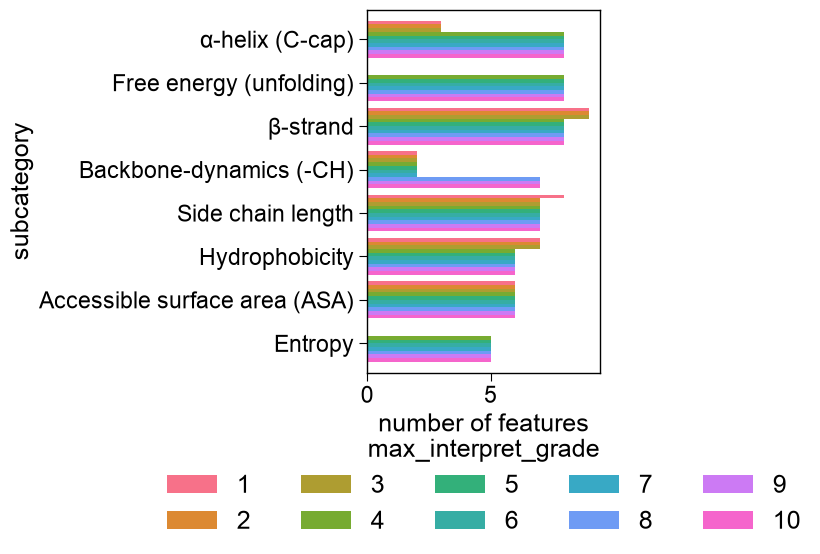

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

levels = list(range(1, 11))
colors = aa.plot_get_clist(n_colors=10)
counts = {g: cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=g)
          ["subcategory"].value_counts() for g in levels}
df_levels = pd.DataFrame(counts).fillna(0).astype(int)
print(df_levels)

top_subcats = df_levels[10].sort_values(ascending=False).head(8).index
df_plot = df_levels.loc[top_subcats]

aa.plot_settings(weight_bold=False)
ax = df_plot.plot(kind="barh", figsize=(7, 6), color=colors, width=0.85, legend=False)
ax.invert_yaxis()
ax.set_xlabel("number of features")
ax.set_ylabel("subcategory")
ax.legend(title="max_interpret_grade", labels=[str(g) for g in levels],
          loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
plt.tight_layout()
plt.show()

**Further parameters.** ``allow_drop`` controls whether ``simplify`` may remove features at all. With ``allow_drop=False`` it only swaps scales and never drops a feature, so the output keeps every input feature 1:1 (redundancy reduction is skipped and ``on_unimprovable`` is forced to ``'keep'``):

In [16]:
df_no_drop = cpp.simplify(df_feat=df_feat, labels=labels, max_interpret_grade=2,
                          allow_drop=False)
print(f"input features: {len(df_feat)}  ->  kept (allow_drop=False): {len(df_no_drop)}")
aa.display_df(df_no_drop, show_shape=True)

input features: 150  ->  kept (allow_drop=False): 150
DataFrame shape: (150, 15)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions,feat_importance,feat_importance_std
1,"TMD_C_JMD_C-Seg...3,4)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.244000,0.103666,0.103666,0.106692,0.110506,0.000000,0.000000,"31,32,33,34,35",0.970400,1.438918
2,"TMD_C_JMD_C-Seg...3,4)-FINA910104",Conformation,α-helix (C-cap),α-helix termination,"Helix terminati...n et al., 1991)",0.243000,0.085064,0.085064,0.098774,0.096946,0.000000,0.000000,"31,32,33,34,35",0.000000,0.000000
3,"TMD_C_JMD_C-Seg...6,9)-LEVM760105",Shape,Side chain length,Side chain length,"Radius of gyrat... (Levitt, 1976)",0.233000,0.137044,0.137044,0.161683,0.176964,0.000000,0.000001,"32,33",1.554800,2.109848
4,"TMD_C_JMD_C-Seg...3,4)-LINS030101",ASA/Volume,Volume,Accessible surface area (ASA),"Total accessibl...s et al., 2003)",0.320000,0.169587,0.169587,0.121842,0.141194,0.000000,0.000000,"31,32,33,34,35",nan,nan
5,"TMD_C_JMD_C-Seg...6,9)-RADA880106",ASA/Volume,Volume,Accessible surface area (ASA),"Accessible surf...olfenden, 1988)",0.223000,0.095071,0.095071,0.114758,0.132829,0.000000,0.000002,"32,33",0.000000,0.000000
6,"TMD_C_JMD_C-Seg...2,3)-KLEP840101",Energy,Charge,Charge,"Net charge (Kle...n et al., 1984)",0.222000,0.058671,0.058671,0.064895,0.069547,0.000000,0.000001,"27,28,29,30,31,32,33",0.000000,0.000000
7,"TMD_C_JMD_C-Seg...4,5)-GUYH850105",ASA/Volume,Accessible surface area (ASA),Partition energy,"Apparent partit...dex (Guy, 1985)",0.299000,0.197679,0.197679,0.157550,0.173685,0.000000,0.000000,"33,34,35,36",nan,nan
8,"TMD_C_JMD_C-Seg...3,4)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),"Average accessi...n et al., 1978)",0.215000,0.124317,0.124317,0.166309,0.153364,0.000000,0.000004,"31,32,33,34,35",1.080400,1.296094
9,"TMD_C_JMD_C-Seg...,10)-WILM950103",Polarity,Hydrophobicity (interface),Hydrophobicity (interface),"Hydrophobicity ...e et al., 1995)",0.212000,0.141305,-0.141305,0.168603,0.217235,0.000000,0.000005,"33,34",1.747200,2.150664
10,"TMD_C_JMD_C-Seg...6,9)-AURR980110",Conformation,α-helix,α-helix (middle),"Normalized posi...ora-Rose, 1998)",0.211000,0.125350,0.125350,0.160819,0.174121,0.000000,0.000005,"32,33",1.788800,2.700803
